In [25]:
from langchain_openrouter import ChatOpenRouter
import getpass
import os
from dotenv import load_dotenv
from IPython.display import display, Markdown

load_dotenv()

if not os.getenv("OPENROUTER_API_KEY"):
    os.environ["OPENROUTER_API_KEY"] = getpass.getpass("Enter your OpenRouter API key: ")

if not os.getenv("LANGSMITH_API_KEY"):
    os.environ["LANGSMITH_API_KEY"] = getpass.getpass("Enter your LangSmith API key: ")


model = ChatOpenRouter(
    model="openai/gpt-3.5-turbo",
    max_tokens=400,
    # reasoning={'effort': 'minimal'}
)

### Intro

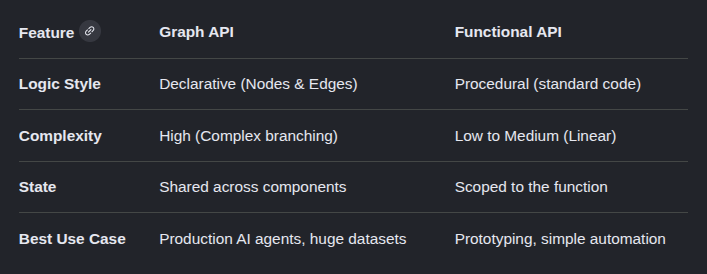

#### Using Graph API

In [26]:
# 1. Define tools and model
from langchain.tools import tool
from langchain.chat_models import init_chat_model

@tool
def multiply(a: int, b: int) -> int:
    """Multiply `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a * b


@tool
def add(a: int, b: int) -> int:
    """Adds `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a + b


@tool
def divide(a: int, b: int) -> float:
    """Divide `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a / b

tools = [add, multiply, divide]
tools_by_name = {tool.name: tool for tool in tools}
model_with_tools = model.bind_tools(tools)

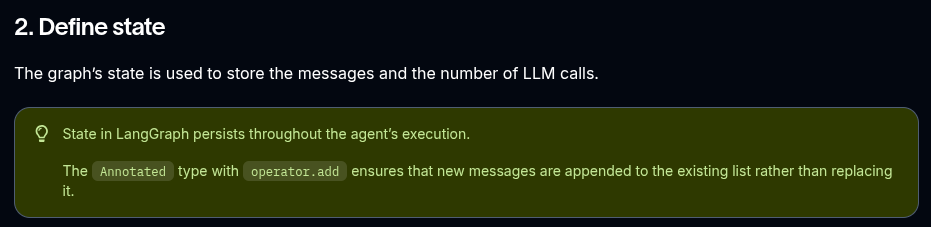

In [27]:
from langchain.messages import AnyMessage
from typing_extensions import TypedDict, Annotated
import operator

class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]
    llm_calls: int

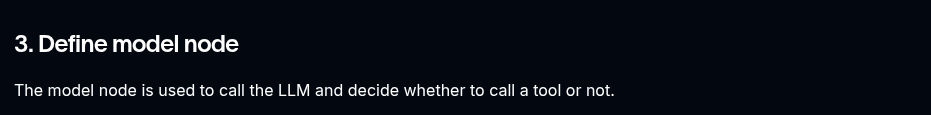

In [28]:
from langchain.messages import SystemMessage

def llm_call(state: dict):
    """LLM decides whether to call a tool or not"""

    return {
        'messages': [
            model_with_tools.invoke(
                [
                    SystemMessage(content='You are a helpful assistant tasked with performing arithmetic on a set of inputs.')
                ]
                + state['messages']
            )
        ],
        'llm_calls': state.get('llm_calls',0) + 1
    }

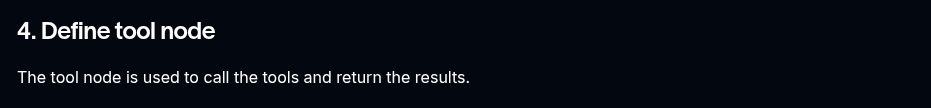

In [29]:
from langchain.messages import ToolMessage

def tool_node(state: dict):
    """Perform the tool call"""

    result = []
    for tool_call in state['messages'][-1].tool_calls:
        tool = tools_by_name[tool_call['name']]
        observation = tool.invoke(tool_call['args'])
        result.append(ToolMessage(content=observation, tool_call_id=tool_call['id']))
    return {'messages': result}

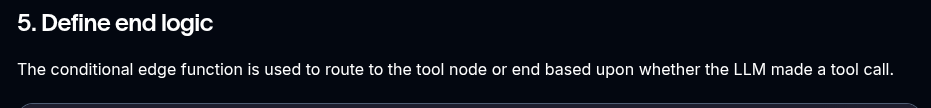

In [30]:
from typing import Literal
from langgraph.graph import StateGraph, START, END


def should_continue(state: MessagesState) -> Literal["tool_node", END]:
    """Decide if we should continue the loop or stop based upon whether the LLM made a tool call"""

    messages = state["messages"]
    last_message = messages[-1]

    # If the LLM makes a tool call, then perform an action
    if last_message.tool_calls:
        return "tool_node"

    # Otherwise, we stop (reply to the user)
    return END

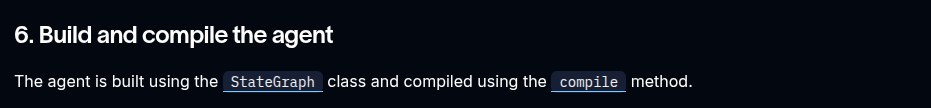

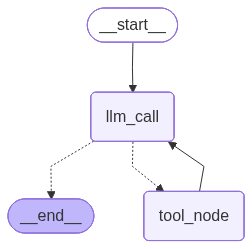

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================
Tool Calls:
  add (call_RWSl5OhBNABnbZsD8DNy9qjv)
 Call ID: call_RWSl5OhBNABnbZsD8DNy9qjv
  Args:
    a: 3
    b: 4
================================= Tool Message =================================

7
================================== Ai Message ==================================

The sum of 3 and 4 is 7.


In [31]:
# Build workflow
agent_builder = StateGraph(MessagesState)

# Add nodes
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)

# Add edges to connect nodes
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    ["tool_node", END]
)
agent_builder.add_edge("tool_node", "llm_call")

# Compile the agent
agent = agent_builder.compile()

# Show the agent
from IPython.display import Image, display
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

# Invoke
from langchain.messages import HumanMessage
messages = [HumanMessage(content="Add 3 and 4.")]
messages = agent.invoke({"messages": messages})
for m in messages["messages"]:
    m.pretty_print()

#### Using Functional API

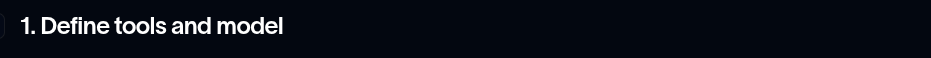

In [32]:
from langchain.tools import tool
from langchain.chat_models import init_chat_model

@tool
def multiply(a: int, b: int) -> int:
    """Multiply `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a * b


@tool
def add(a: int, b: int) -> int:
    """Adds `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a + b


@tool
def divide(a: int, b: int) -> float:
    """Divide `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a / b


# Augment the LLM with tools
tools = [add, multiply, divide]
tools_by_name = {tool.name: tool for tool in tools}
model_with_tools = model.bind_tools(tools)

from langgraph.graph import add_messages
from langchain.messages import (
    SystemMessage,
    HumanMessage,
    ToolCall,
)
from langchain_core.messages import BaseMessage
from langgraph.func import entrypoint, task

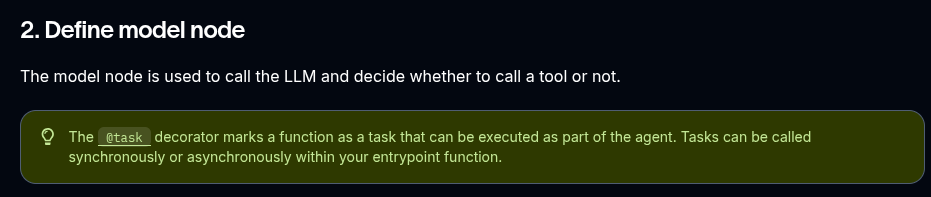

In [33]:
@task
def call_llm(messages: list[BaseMessage]):
    """LLM decides whether to call a tool or not"""
    return model_with_tools.invoke(
        [
            SystemMessage(
                content="You are a helpful assistant tasked with performing arithmetic on a set of inputs."
            )
        ]
        + messages
    )

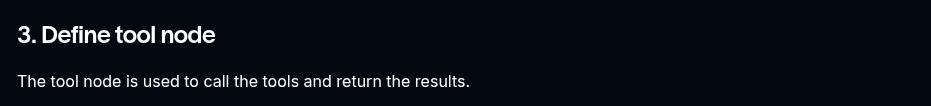

In [34]:
@task
def call_tool(tool_call: ToolCall):
    """Perform the tool call"""
    tool = tools_by_name[tool_call['name']]
    return tool.invoke(tool_call)

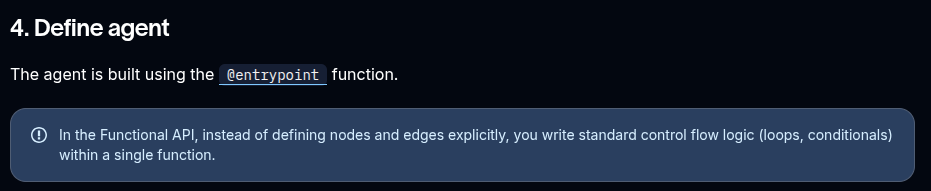

In [35]:
@entrypoint()
def agent(messages: list[BaseMessage]):
    model_response = call_llm(messages).result()

    while True:
        if not model_response.tool_calls:
            break

        tool_result_futures = [call_tool(tool_call) for tool_call in model_response.tool_calls]
        tool_results = [fut.result() for fut in tool_result_futures]
        messages = add_messages(messages, [model_response, *tool_results])
        model_response = call_llm(messages).result()

    messages = add_messages(messages, model_response)
    return messages

messages = [HumanMessage(content='Add 3 and 4.')]
for chunk in agent.stream(messages, stream_mode='updates'):
    print(chunk)
    print('\n')

{'call_llm': AIMessage(content='', additional_kwargs={}, response_metadata={'model_name': 'openai/gpt-3.5-turbo', 'id': 'gen-1779681697-EbpdaLV5UeM7H0yi3nzK', 'created': 1779681697, 'object': 'chat.completion', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'openrouter'}, id='lc_run--019e5d4b-9d2a-7a51-a454-f0a85795cb4b-0', tool_calls=[{'name': 'add', 'args': {'a': 3, 'b': 4}, 'id': 'call_1rmhQzQMKnjWQtcn65yWp5Dt', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 171, 'output_tokens': 17, 'total_tokens': 188, 'input_token_details': {'cache_read': 0, 'cache_creation': 0}, 'output_token_details': {'reasoning': 0}})}


{'call_tool': ToolMessage(content='7', name='add', tool_call_id='call_1rmhQzQMKnjWQtcn65yWp5Dt')}


{'call_llm': AIMessage(content='The sum of 3 and 4 is 7.', additional_kwargs={}, response_metadata={'model_name': 'openai/gpt-3.5-turbo', 'id': 'gen-1779681697-Hres8WmpsCkNaXWA5sjh', 'created': 1779681697, 'object': 'chat.compl

### Thinking in LangGraph

In [36]:
# Define State
from typing import TypedDict, Literal

class EmailClassification(TypedDict):
    intent: Literal['question','bug','billing','feature','complex']
    urgency: Literal['low','medium','high','critical']
    topic: str
    summary: str

class EmailAgentState(TypedDict):
    email_content: str
    sender_email: str
    email_id: str

    classification: EmailClassification | None

    search_results: list[str] | None
    customer_history: dict | None

    draft_response: str | None
    messages: list[str] | None


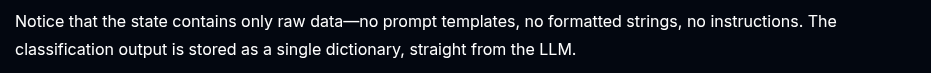

- Read and Classify nodes

In [37]:
from typing import Literal
from langgraph.graph import StateGraph, START, END
from langgraph.types import interrupt, Command, RetryPolicy
from langchain.messages import HumanMessage

llm = model

def read_email(state: EmailAgentState) -> dict:
    """Extract and parse email content"""

    return {
        "messages": [HumanMessage(content=f"Processing email: {state['email_content']}")]
    }

def classify_intent(state: EmailAgentState) -> Command[Literal["search_documentation", "human_review", "draft_response", "bug_tracking"]]:
    """Use LLM to classify email intent and urgency, then route accordingly"""

    # Create structured LLM that returns EmailClassification dict
    structured_llm = llm.with_structured_output(EmailClassification)

    # Format the prompt on-demand, not stored in state
    classification_prompt = f"""
    Analyze this customer email and classify it:

    Email: {state['email_content']}
    From: {state['sender_email']}

    Provide classification including intent, urgency, topic, and summary.
    """

    # Get structured response directly as dict
    classification = structured_llm.invoke(classification_prompt)

    # Determine next node based on classification
    if classification['intent'] == 'billing' or classification['urgency'] == 'critical':
        goto = "human_review"
    elif classification['intent'] in ['question', 'feature']:
        goto = "search_documentation"
    elif classification['intent'] == 'bug':
        goto = "bug_tracking"
    else:
        goto = "draft_response"

    # Store classification as a single dict in state
    return Command(
        update={"classification": classification},
        goto=goto
    )

- Search and tracking nodes

In [38]:
def search_documentation(state: EmailAgentState) -> Command[Literal["draft_response"]]:
    """Search knowledge base for relevant information"""

    # Build search query from classification
    classification = state.get('classification', {})
    query = f"{classification.get('intent', '')} {classification.get('topic', '')}"

    try:
        # Implement your search logic here
        # Store raw search results, not formatted text
        search_results = [
            "Reset password via Settings > Security > Change Password",
            "Password must be at least 12 characters",
            "Include uppercase, lowercase, numbers, and symbols"
        ]
    except SearchAPIError as e:
        # For recoverable search errors, store error and continue
        search_results = [f"Search temporarily unavailable: {str(e)}"]

    return Command(
        update={"search_results": search_results},  # Store raw results or error
        goto="draft_response"
    )

def bug_tracking(state: EmailAgentState) -> Command[Literal["draft_response"]]:
    """Create or update bug tracking ticket"""

    # Create ticket in your bug tracking system
    ticket_id = "BUG-12345"  # Would be created via API

    return Command(
        update={
            "search_results": [f"Bug ticket {ticket_id} created"],
            "current_step": "bug_tracked"
        },
        goto="draft_response"
    )

- Response nodes

In [39]:
def draft_response(state: EmailAgentState) -> Command[Literal["human_review", "send_reply"]]:
    """Generate response using context and route based on quality"""

    classification = state.get('classification', {})

    # Format context from raw state data on-demand
    context_sections = []

    if state.get('search_results'):
        # Format search results for the prompt
        formatted_docs = "\n".join([f"- {doc}" for doc in state['search_results']])
        context_sections.append(f"Relevant documentation:\n{formatted_docs}")

    if state.get('customer_history'):
        # Format customer data for the prompt
        context_sections.append(f"Customer tier: {state['customer_history'].get('tier', 'standard')}")

    # Build the prompt with formatted context
    draft_prompt = f"""
    Draft a response to this customer email:
    {state['email_content']}

    Email intent: {classification.get('intent', 'unknown')}
    Urgency level: {classification.get('urgency', 'medium')}

    {chr(10).join(context_sections)}

    Guidelines:
    - Be professional and helpful
    - Address their specific concern
    - Use the provided documentation when relevant
    """

    response = llm.invoke(draft_prompt)

    # Determine if human review needed based on urgency and intent
    needs_review = (
        classification.get('urgency') in ['high', 'critical'] or
        classification.get('intent') == 'complex'
    )

    # Route to appropriate next node
    goto = "human_review" if needs_review else "send_reply"

    return Command(
        update={"draft_response": response.content},  # Store only the raw response
        goto=goto
    )

def human_review(state: EmailAgentState) -> Command[Literal["send_reply", END]]:
    """Pause for human review using interrupt and route based on decision"""

    classification = state.get('classification', {})

    # interrupt() must come first - any code before it will re-run on resume
    human_decision = interrupt({
        "email_id": state.get('email_id',''),
        "original_email": state.get('email_content',''),
        "draft_response": state.get('draft_response',''),
        "urgency": classification.get('urgency'),
        "intent": classification.get('intent'),
        "action": "Please review and approve/edit this response"
    })

    # Now process the human's decision
    if human_decision.get("approved"):
        return Command(
            update={"draft_response": human_decision.get("edited_response", state.get('draft_response',''))},
            goto="send_reply"
        )
    else:
        # Rejection means human will handle directly
        return Command(update={}, goto=END)

def send_reply(state: EmailAgentState) -> dict:
    """Send the email response"""
    # Integrate with email service
    print(f"Sending reply: {state['draft_response'][:100]}...")
    return {}

- Graph compilation code

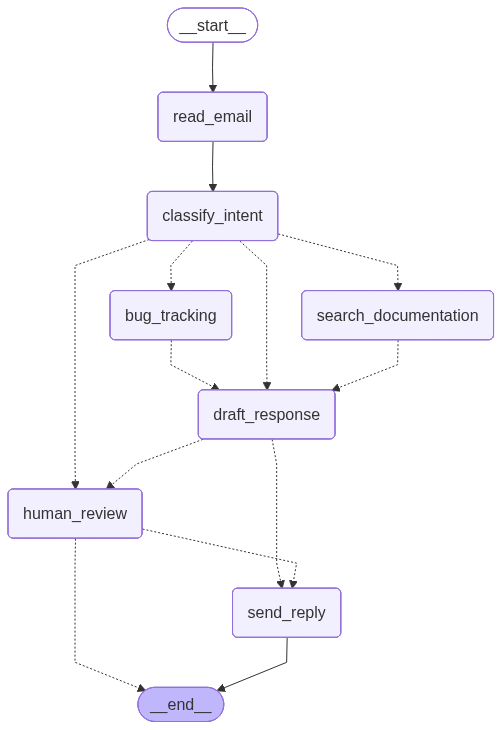

In [40]:
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import RetryPolicy

# Create the graph
workflow = StateGraph(EmailAgentState)

# Add nodes with appropriate error handling
workflow.add_node("read_email", read_email)
workflow.add_node("classify_intent", classify_intent)

# Add retry policy for nodes that might have transient failures
workflow.add_node(
    "search_documentation",
    search_documentation,
    retry_policy=RetryPolicy(max_attempts=3)
)
workflow.add_node("bug_tracking", bug_tracking)
workflow.add_node("draft_response", draft_response)
workflow.add_node("human_review", human_review)
workflow.add_node("send_reply", send_reply)

# Add only the essential edges
workflow.add_edge(START, "read_email")
workflow.add_edge("read_email", "classify_intent")
workflow.add_edge("send_reply", END)

# Compile with checkpointer for persistence, in case run graph with Local_Server --> Please compile without checkpointer
memory = MemorySaver()
app = workflow.compile(checkpointer=memory)

display(Image(app.get_graph(xray=True).draw_mermaid_png()))

- Testing the agent

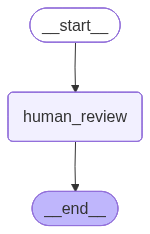

human review interrupt:(Interrupt(value={'approved': False, 'edited_response': 'Draft response'}, id='7fc7a3b6d8534825da3ef8422df78a7c'),)


In [41]:
from typing import TypedDict

from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command, interrupt


class EmailState(TypedDict):
    email_content: str
    response_text: str | None


def human_review_node(state: EmailState):
    interrupt(
        {
            "approved": False,
            "edited_response": state.get("response_text") or "",
        }
    )
    return {"response_text": "placeholder"}


app = (
    StateGraph(EmailState)
    .add_node("human_review", human_review_node)
    .add_edge(START, "human_review")
    .add_edge("human_review", END)
    .compile(checkpointer=InMemorySaver())
)

display(Image(app.get_graph(xray=True).draw_mermaid_png()))

initial_state = {
    "email_content": "I was charged twice for my subscription! This is urgent!",
    "response_text": "Draft response",
}

# Run with a thread_id for persistence
config = {"configurable": {"thread_id": "customer_1234"}}
result = app.invoke(initial_state, config, version="v2")
# The graph will pause at human_review
print(f"human review interrupt:{result.interrupts}")

In [42]:
human_response = Command(
    resume={
        "approved": True,
        "edited_response": "We sincerely apologize for the double charge. I've initiated an immediate refund...",
    }
)

# Resume execution
final_result = app.invoke(human_response, config, version="v2")
print("Email sent successfully!")

Email sent successfully!


In [43]:
final_result

GraphOutput(value={'email_content': 'I was charged twice for my subscription! This is urgent!', 'response_text': 'placeholder'}, interrupts=())

### Workflows and Agents

In [44]:
# Schema for structured output
from pydantic import BaseModel, Field


class SearchQuery(BaseModel):
    search_query: str = Field(None, description="Query that is optimized web search.")
    justification: str = Field(
        None, description="Why this query is relevant to the user's request."
    )


# Augment the LLM with schema for structured output
structured_llm = llm.with_structured_output(SearchQuery)

# Invoke the augmented LLM
output = structured_llm.invoke("How does Calcium CT score relate to high cholesterol?")

# Define a tool
def multiply(a: int, b: int) -> int:
    return a * b

# Augment the LLM with tools
llm_with_tools = llm.bind_tools([multiply])

# Invoke the LLM with input that triggers the tool call
msg = llm_with_tools.invoke("What is 2 times 3?")

# Get the tool call
msg.tool_calls

[{'name': 'multiply',
  'args': {'a': 2, 'b': 3},
  'id': 'call_dkrmKP6YcLaIQzmFpLkHpT9Y',
  'type': 'tool_call'}]

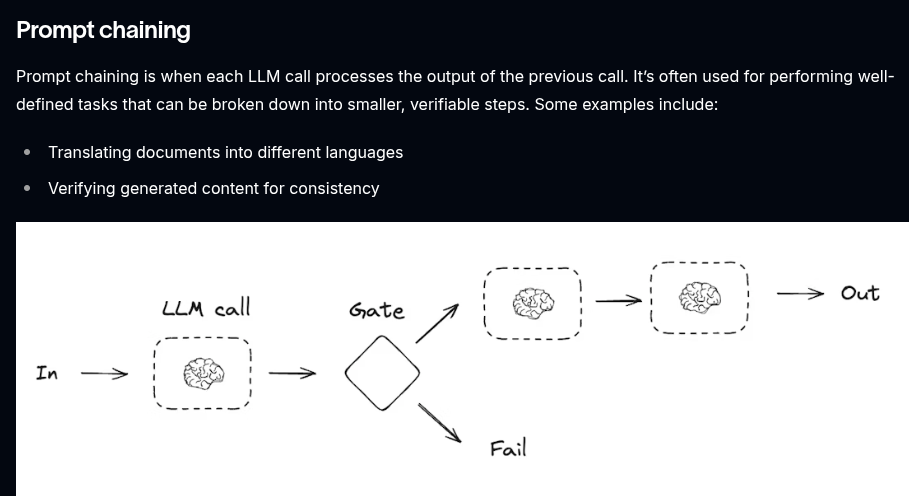

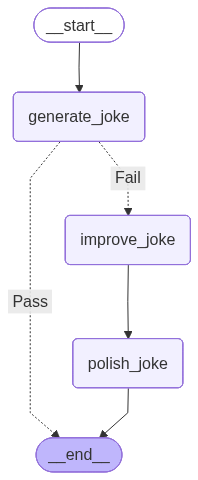

Initial joke:
Why was the cat sitting on the computer?

Because it wanted to keep an eye on the mouse!

--- --- ---

Final joke:
Why was the cat sitting on the computer?

Because it wanted to keep an eye on the mouse!


In [45]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display


# Graph state
class State(TypedDict):
    topic: str
    joke: str
    improved_joke: str
    final_joke: str


# Nodes
def generate_joke(state: State):
    """First LLM call to generate initial joke"""

    msg = llm.invoke(f"Write a short joke about {state['topic']}")
    return {"joke": msg.content}


def check_punchline(state: State):
    """Gate function to check if the joke has a punchline"""

    # Simple check - does the joke contain "?" or "!"
    if "?" in state["joke"] or "!" in state["joke"]:
        return "Pass"
    return "Fail"


def improve_joke(state: State):
    """Second LLM call to improve the joke"""

    msg = llm.invoke(f"Make this joke funnier by adding wordplay: {state['joke']}")
    return {"improved_joke": msg.content}


def polish_joke(state: State):
    """Third LLM call for final polish"""
    msg = llm.invoke(f"Add a surprising twist to this joke: {state['improved_joke']}")
    return {"final_joke": msg.content}


# Build workflow
workflow = StateGraph(State)

# Add nodes
workflow.add_node("generate_joke", generate_joke)
workflow.add_node("improve_joke", improve_joke)
workflow.add_node("polish_joke", polish_joke)

# Add edges to connect nodes
workflow.add_edge(START, "generate_joke")
workflow.add_conditional_edges(
    "generate_joke", check_punchline, {"Fail": "improve_joke", "Pass": END}
)
workflow.add_edge("improve_joke", "polish_joke")
workflow.add_edge("polish_joke", END)

# Compile
chain = workflow.compile()

# Show workflow
display(Image(chain.get_graph().draw_mermaid_png()))

# Invoke
state = chain.invoke({"topic": "cats"})
print("Initial joke:")
print(state["joke"])
print("\n--- --- ---\n")
if "improved_joke" in state:
    print("Improved joke:")
    print(state["improved_joke"])
    print("\n--- --- ---\n")

    print("Final joke:")
    print(state["final_joke"])
else:
    print("Final joke:")
    print(state["joke"])

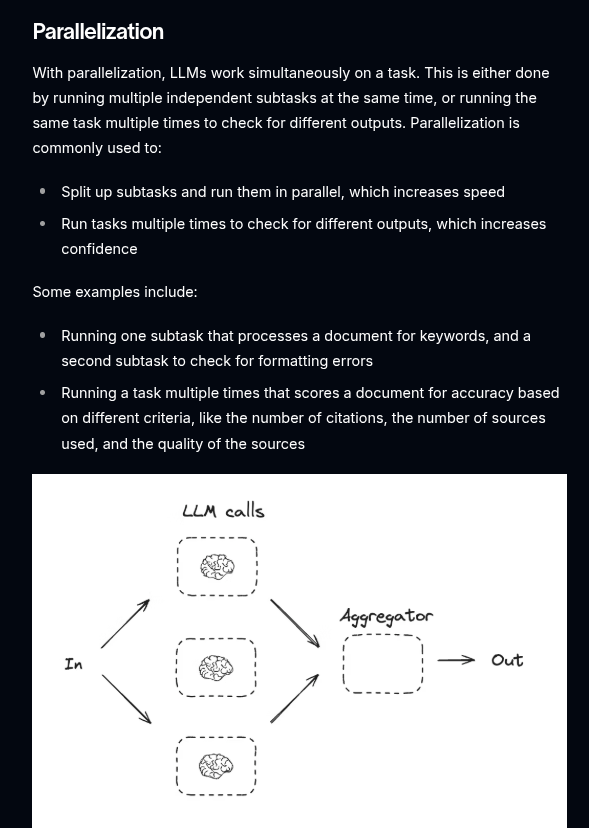

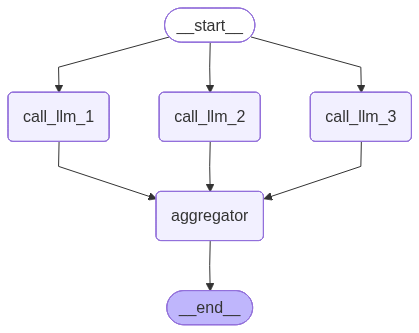

Here's a story, joke, and poem about cats!

STORY:
Once upon a time in a small town, there lived a group of cats who were all best friends. They spent their days lounging in the sun, chasing mice, and playing with each other in the town square.

One day, a new cat arrived in town. She was a beautiful white cat with bright green eyes and a fluffy tail. The other cats were curious about her and quickly welcomed her into their group.

The white cat, whose name was Luna, quickly became the leader of the group. She was wise and kind, and the other cats looked up to her. Luna taught them new tricks, like how to catch birds and climb trees, and they all loved her dearly.

But one day, disaster struck. A group of mean dogs came into town and started causing trouble. They chased the cats away from the town square and made it impossible for them to relax and play together.

The cats were scared and didn't know what to do. But Luna stepped up and came up with a plan. She went to talk to the dogs 

In [46]:
# Graph state
class State(TypedDict):
    topic: str
    joke: str
    story: str
    poem: str
    combined_output: str


# Nodes
def call_llm_1(state: State):
    """First LLM call to generate initial joke"""

    msg = llm.invoke(f"Write a joke about {state['topic']}")
    return {"joke": msg.content}


def call_llm_2(state: State):
    """Second LLM call to generate story"""

    msg = llm.invoke(f"Write a story about {state['topic']}")
    return {"story": msg.content}


def call_llm_3(state: State):
    """Third LLM call to generate poem"""

    msg = llm.invoke(f"Write a poem about {state['topic']}")
    return {"poem": msg.content}


def aggregator(state: State):
    """Combine the joke, story and poem into a single output"""

    combined = f"Here's a story, joke, and poem about {state['topic']}!\n\n"
    combined += f"STORY:\n{state['story']}\n\n"
    combined += f"JOKE:\n{state['joke']}\n\n"
    combined += f"POEM:\n{state['poem']}"
    return {"combined_output": combined}


# Build workflow
parallel_builder = StateGraph(State)

# Add nodes
parallel_builder.add_node("call_llm_1", call_llm_1)
parallel_builder.add_node("call_llm_2", call_llm_2)
parallel_builder.add_node("call_llm_3", call_llm_3)
parallel_builder.add_node("aggregator", aggregator)

# Add edges to connect nodes
parallel_builder.add_edge(START, "call_llm_1")
parallel_builder.add_edge(START, "call_llm_2")
parallel_builder.add_edge(START, "call_llm_3")
parallel_builder.add_edge("call_llm_1", "aggregator")
parallel_builder.add_edge("call_llm_2", "aggregator")
parallel_builder.add_edge("call_llm_3", "aggregator")
parallel_builder.add_edge("aggregator", END)
parallel_workflow = parallel_builder.compile()

# Show workflow
display(Image(parallel_workflow.get_graph().draw_mermaid_png()))

# Invoke
state = parallel_workflow.invoke({"topic": "cats"})
print(state["combined_output"])

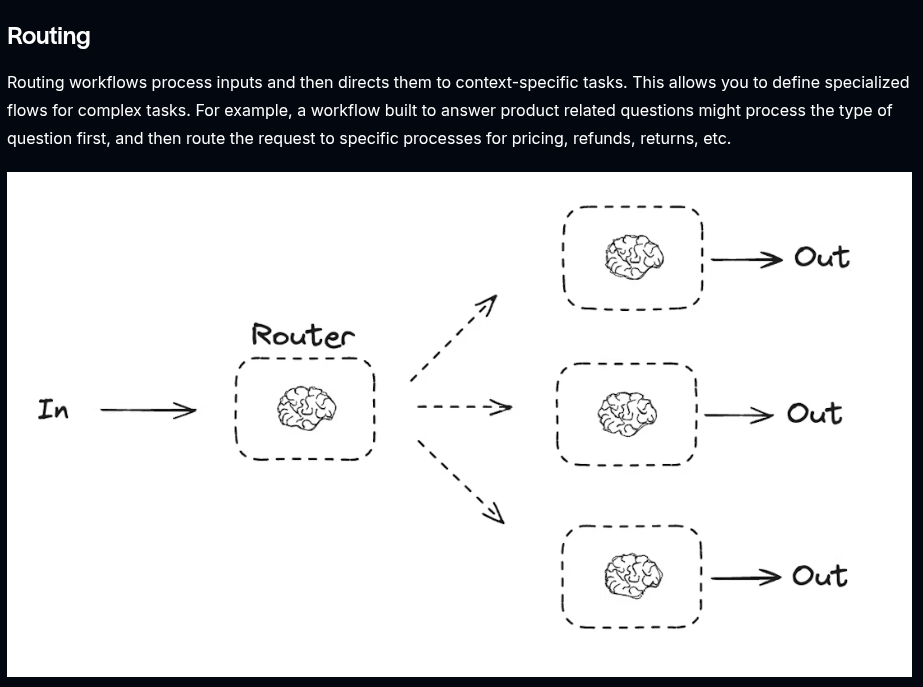

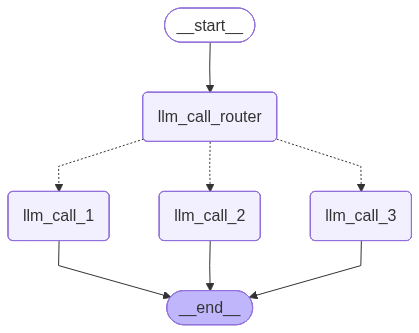

Why did the dog sit in the shade during obedience class? Because he didn't want to be a hot dog!


In [47]:
from typing_extensions import Literal
from langchain.messages import HumanMessage, SystemMessage


# Schema for structured output to use as routing logic
class Route(BaseModel):
    step: Literal["poem", "story", "joke"] = Field(
        None, description="The next step in the routing process"
    )


# Augment the LLM with schema for structured output
router = llm.with_structured_output(Route)


# State
class State(TypedDict):
    input: str
    decision: str
    output: str


# Nodes
def llm_call_1(state: State):
    """Write a story"""

    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_2(state: State):
    """Write a joke"""

    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_3(state: State):
    """Write a poem"""

    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_router(state: State):
    """Route the input to the appropriate node"""

    # Run the augmented LLM with structured output to serve as routing logic
    decision = router.invoke(
        [
            SystemMessage(
                content="Route the input to story, joke, or poem based on the user's request."
            ),
            HumanMessage(content=state["input"]),
        ]
    )

    return {"decision": decision.step}


# Conditional edge function to route to the appropriate node
def route_decision(state: State):
    # Return the node name you want to visit next
    if state["decision"] == "story":
        return "llm_call_1"
    elif state["decision"] == "joke":
        return "llm_call_2"
    elif state["decision"] == "poem":
        return "llm_call_3"


# Build workflow
router_builder = StateGraph(State)

# Add nodes
router_builder.add_node("llm_call_1", llm_call_1)
router_builder.add_node("llm_call_2", llm_call_2)
router_builder.add_node("llm_call_3", llm_call_3)
router_builder.add_node("llm_call_router", llm_call_router)

# Add edges to connect nodes
router_builder.add_edge(START, "llm_call_router")
router_builder.add_conditional_edges(
    "llm_call_router",
    route_decision,
    {  # Name returned by route_decision : Name of next node to visit
        "llm_call_1": "llm_call_1",
        "llm_call_2": "llm_call_2",
        "llm_call_3": "llm_call_3",
    },
)
router_builder.add_edge("llm_call_1", END)
router_builder.add_edge("llm_call_2", END)
router_builder.add_edge("llm_call_3", END)

# Compile workflow
router_workflow = router_builder.compile()

# Show the workflow
display(Image(router_workflow.get_graph().draw_mermaid_png()))

# Invoke
state = router_workflow.invoke({"input": "Write me a joke about dogs"})
print(state["output"])

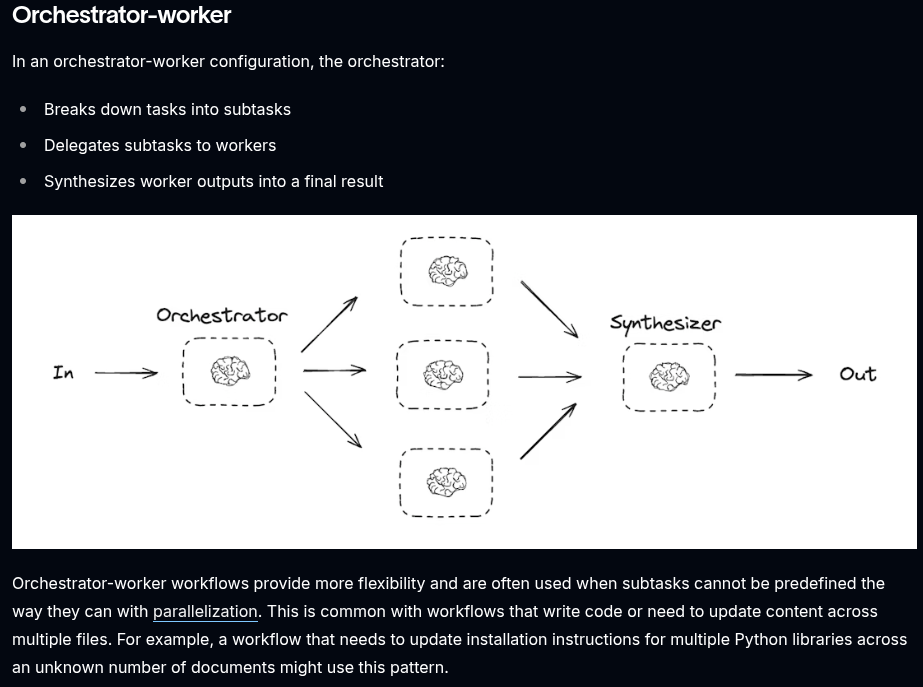

In [48]:
from typing import Annotated, List
import operator


# Schema for structured output to use in planning
class Section(BaseModel):
    name: str = Field(
        description="Name for this section of the report.",
    )
    description: str = Field(
        description="Brief overview of the main topics and concepts to be covered in this section.",
    )


class Sections(BaseModel):
    sections: List[Section] = Field(
        description="Sections of the report.",
    )


# Augment the LLM with schema for structured output
planner = llm.with_structured_output(Sections)

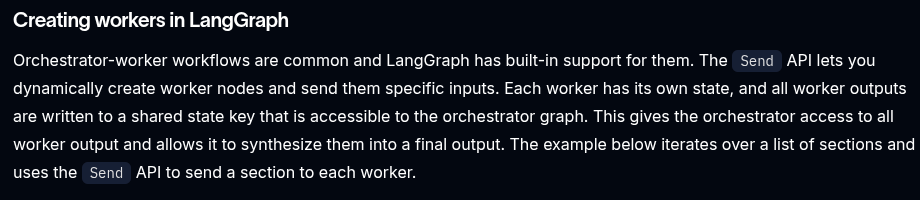

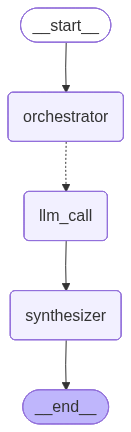

## Introduction

LLM scaling laws are a set of principles used to predict the behavior of complex systems based on the sizes of their components. These laws provide insight into how different properties scale with system size and are crucial in understanding the behavior of various systems in diverse fields such as physics, biology, economics, and engineering. By identifying common patterns in the scaling of different parameters, LLM scaling laws help researchers make predictions, optimize designs, and uncover underlying principles governing complex systems.

---

## Overview of LLM Scaling Laws

LLM scaling laws refer to the mathematical relationships that govern the scalability of large language models (LLMs) such as GPT-3 and BERT. These scaling laws help in understanding how the performance of LLMs changes with an increase in model size, training data, or computational resources. By analyzing these scaling laws, researchers can optimize the development and deployment of LLMs in various applications, ranging from natural language processing to machine translation and question-answering systems.

---

## Types of LLM Scaling Laws

There are several types of LLM (Large Language Models) scaling laws that have been proposed in the field of artificial intelligence. These scaling laws help determine the relationship between the size of the model and its performance. Some of the common types include:

1. **Parameter Scaling Laws**: These scaling laws focus on how the number of parameters in a model affects its performance. As the number of parameters increases, the model's capacity to understand and generate more complex patterns also increases.

2. **Compute Scaling Laws**: Compute scaling laws examine the relationship between the computational resources required to train a model and its size. Larger models often require more computational power and time to train effectively.

3. **Data Scaling Laws**: Data scaling laws look at how the amount of training data influences the performance of large language models. More data can help improve the model's generalization and ability to handle a wide range of tasks.

4. **Efficiency Scaling Laws**: Efficiency scaling laws focus on balancing the performance of a model with the resources needed to train and deploy it. These laws aim to find the optimal trade-off between model size, computational cost, and performance.

Each type of scaling law has its own characteristics and implications for the design and implementation of large language models. By understanding these scaling laws, researchers and practitioners can make informed decisions when developing and utilizing LLMs in various applications.

---

## Applications of LLM Scaling Laws

Explore real-world applications of LLM scaling laws in industries like physics, engineering, biology, and more.

---

## Challenges and Limitations

- **Data Availability:** One of the major challenges in implementing LLM scaling laws is the availability of high-quality data. The accuracy and reliability of the results obtained from these laws heavily depend on the quality and quantity of data used for analysis. Obtaining large and diverse datasets that cover a wide range of conditions and parameters can be a challenging task.

- **Generalizability:** Another limitation of LLM scaling laws is the issue of generalizability. These laws are often derived from specific experimental or empirical data, which may not always be applicable to different scenarios or systems. The assumptions made in developing the scaling laws may not hold true in all cases, leading to inaccuracies in predictions.

- **Complexity and Non-linearity:** The scaling laws for LLM systems can become highly complex and non-linear, especially when dealing with multiple interacting parameters. Managing and interpreting these complex relationships can be challenging and may require advanced mathematical and computational tools.

- **Scope of Applications:** While LLM scaling laws have been successfully applied in various fields like material science, biology, and engineering, their applicability may be limited in certain niche areas or under extreme conditions. The laws may not capture all the nuances of a system's behavior, leading to inaccuracies in predictions.

- **Assumptions and Simplifications:** The derivation of scaling laws often involves making simplifying assumptions to model the underlying physics or mechanics of a system. These assumptions may not always hold true in real-world scenarios, leading to discrepancies between theoretical predictions and experimental observations.

- **Verification and Validation:** Validating the accuracy and robustness of LLM scaling laws can be a challenging task. Experimental verification of the predictions derived from these laws may require significant resources and time, making it difficult to fully validate the models under all possible conditions.

---

## Future of LLM Scaling Laws

As technology continues to advance, the field of LLM scaling laws is expected to see several significant developments in the future. One of the key trends that is likely to emerge is the exploration of new materials and technologies to push the limits of miniaturization even further. Researchers are expected to investigate novel dielectric materials, advanced lithography techniques, and innovative device architectures to achieve smaller feature sizes and increased performance in LLM devices.

Additionally, the integration of artificial intelligence and machine learning algorithms into the design and optimization of LLM scaling laws is expected to become more prevalent. These technologies can help researchers identify patterns, predict properties, and optimize parameters more efficiently, leading to faster innovation cycles and improved device performance.

Moreover, the development of quantum computing and its potential impact on LLM scaling laws is poised to be a significant area of research in the future. Quantum computing offers the promise of solving complex calculations at speeds far beyond classical computers, which could revolutionize the design and simulation of LLM devices and scaling laws.

Overall, the future of LLM scaling laws holds exciting possibilities for further miniaturization, increased performance, and novel applications, driven by advancements in materials, technologies, and computational tools.

In [49]:
from langgraph.types import Send


# Graph state
class State(TypedDict):
    topic: str  # Report topic
    sections: list[Section]  # List of report sections
    completed_sections: Annotated[
        list, operator.add
    ]  # All workers write to this key in parallel
    final_report: str  # Final report


# Worker state
class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]


# Nodes
def orchestrator(state: State):
    """Orchestrator that generates a plan for the report"""

    # Generate queries
    report_sections = planner.invoke(
        [
            SystemMessage(content="Generate a plan for the report."),
            HumanMessage(content=f"Here is the report topic: {state['topic']}"),
        ]
    )

    return {"sections": report_sections.sections}


def llm_call(state: WorkerState):
    """Worker writes a section of the report"""

    # Generate section
    section = llm.invoke(
        [
            SystemMessage(
                content="Write a report section following the provided name and description. Include no preamble for each section. Use markdown formatting."
            ),
            HumanMessage(
                content=f"Here is the section name: {state['section'].name} and description: {state['section'].description}"
            ),
        ]
    )

    # Write the updated section to completed sections
    return {"completed_sections": [section.content]}


def synthesizer(state: State):
    """Synthesize full report from sections"""

    # List of completed sections
    completed_sections = state["completed_sections"]

    # Format completed section to str to use as context for final sections
    completed_report_sections = "\n\n---\n\n".join(completed_sections)

    return {"final_report": completed_report_sections}


# Conditional edge function to create llm_call workers that each write a section of the report
def assign_workers(state: State):
    """Assign a worker to each section in the plan"""

    # Kick off section writing in parallel via Send() API
    return [Send("llm_call", {"section": s}) for s in state["sections"]]


# Build workflow
orchestrator_worker_builder = StateGraph(State)

# Add the nodes
orchestrator_worker_builder.add_node("orchestrator", orchestrator)
orchestrator_worker_builder.add_node("llm_call", llm_call)
orchestrator_worker_builder.add_node("synthesizer", synthesizer)

# Add edges to connect nodes
orchestrator_worker_builder.add_edge(START, "orchestrator")
orchestrator_worker_builder.add_conditional_edges(
    "orchestrator", assign_workers, ["llm_call"]
)
orchestrator_worker_builder.add_edge("llm_call", "synthesizer")
orchestrator_worker_builder.add_edge("synthesizer", END)

# Compile the workflow
orchestrator_worker = orchestrator_worker_builder.compile()

# Show the workflow
display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))

# Invoke
state = orchestrator_worker.invoke({"topic": "Create a report on LLM scaling laws"})

from IPython.display import Markdown
Markdown(state["final_report"])

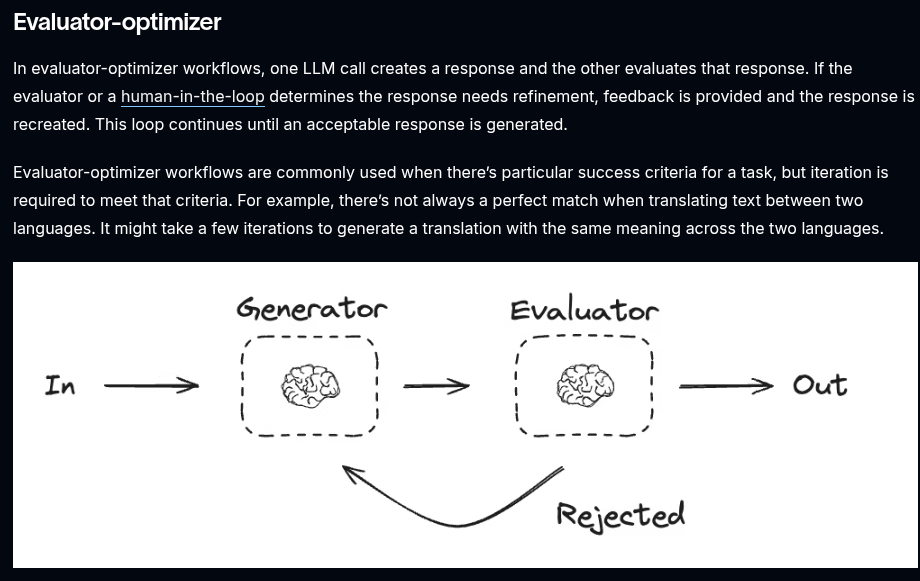

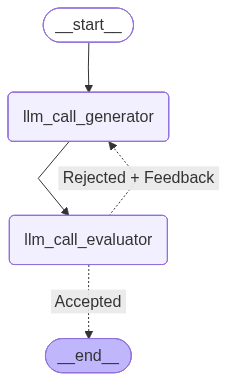

Why did the programmer quit his job? Because he didn't get arrays!


In [50]:
# Graph state
class State(TypedDict):
    joke: str
    topic: str
    feedback: str
    funny_or_not: str


# Schema for structured output to use in evaluation
class Feedback(BaseModel):
    grade: Literal["funny", "not funny"] = Field(
        description="Decide if the joke is funny or not.",
    )
    feedback: str = Field(
        description="If the joke is not funny, provide feedback on how to improve it.",
    )


# Augment the LLM with schema for structured output
evaluator = llm.with_structured_output(Feedback)


# Nodes
def llm_call_generator(state: State):
    """LLM generates a joke"""

    if state.get("feedback"):
        msg = llm.invoke(
            f"Write a joke about {state['topic']} but take into account the feedback: {state['feedback']}"
        )
    else:
        msg = llm.invoke(f"Write a joke about {state['topic']}")
    return {"joke": msg.content}


def llm_call_evaluator(state: State):
    """LLM evaluates the joke"""

    grade = evaluator.invoke(f"Grade the joke {state['joke']}")
    # return {"funny_or_not": grade.grade, "feedback": grade.feedback}
    return {"funny_or_not": grade.grade, "feedback": grade.feedback}


# Conditional edge function to route back to joke generator or end based upon feedback from the evaluator
def route_joke(state: State):
    """Route back to joke generator or end based upon feedback from the evaluator"""

    if state["funny_or_not"] == "funny":
        return "Accepted"
    elif state["funny_or_not"] == "not funny":
        return "Rejected + Feedback"


# Build workflow
optimizer_builder = StateGraph(State)

# Add the nodes
optimizer_builder.add_node("llm_call_generator", llm_call_generator)
optimizer_builder.add_node("llm_call_evaluator", llm_call_evaluator)

# Add edges to connect nodes
optimizer_builder.add_edge(START, "llm_call_generator")
optimizer_builder.add_edge("llm_call_generator", "llm_call_evaluator")
optimizer_builder.add_conditional_edges(
    "llm_call_evaluator",
    route_joke,
    {  # Name returned by route_joke : Name of next node to visit
        "Accepted": END,
        "Rejected + Feedback": "llm_call_generator",
    },
)

# Compile the workflow
optimizer_workflow = optimizer_builder.compile()

# Show the workflow
display(Image(optimizer_workflow.get_graph().draw_mermaid_png()))

# Invoke
state = optimizer_workflow.invoke({"topic": "programming"})

print(state["joke"])

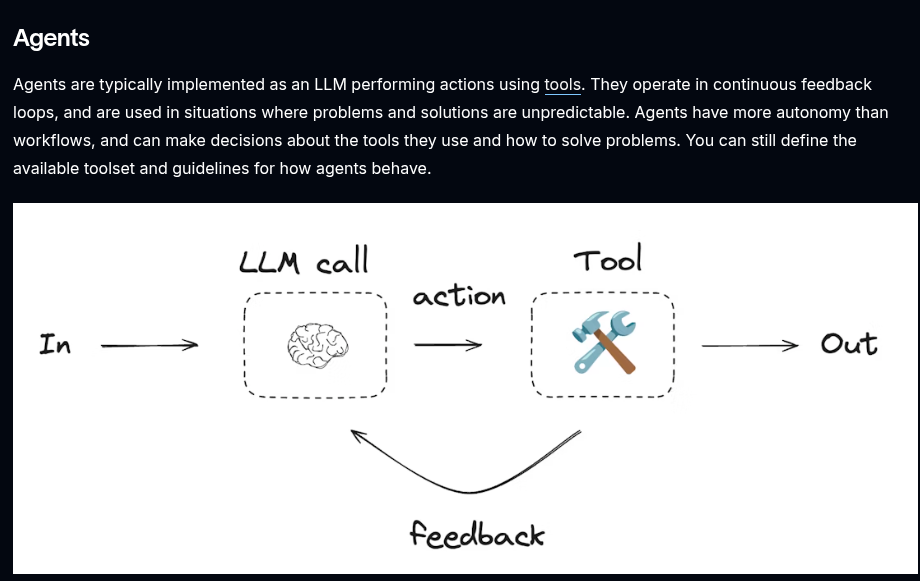

In [51]:
from langchain.tools import tool


# Define tools
@tool
def multiply(a: int, b: int) -> int:
    """Multiply `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a * b


@tool
def add(a: int, b: int) -> int:
    """Adds `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a + b


@tool
def divide(a: int, b: int) -> float:
    """Divide `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a / b


# Augment the LLM with tools
tools = [add, multiply, divide]
tools_by_name = {tool.name: tool for tool in tools}
llm_with_tools = llm.bind_tools(tools)

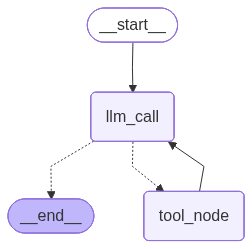

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================
Tool Calls:
  add (call_iyOw4FHEqVvcwiHWdm4edLin)
 Call ID: call_iyOw4FHEqVvcwiHWdm4edLin
  Args:
    a: 3
    b: 4
================================= Tool Message =================================

7
================================== Ai Message ==================================

The sum of 3 and 4 is 7.


In [52]:
from langgraph.graph import MessagesState
from langchain.messages import SystemMessage, HumanMessage, ToolMessage


# Nodes
def llm_call(state: MessagesState):
    """LLM decides whether to call a tool or not"""

    return {
        "messages": [
            llm_with_tools.invoke(
                [
                    SystemMessage(
                        content="You are a helpful assistant tasked with performing arithmetic on a set of inputs."
                    )
                ]
                + state["messages"]
            )
        ]
    }


def tool_node(state: dict):
    """Performs the tool call"""

    result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    return {"messages": result}


# Conditional edge function to route to the tool node or end based upon whether the LLM made a tool call
def should_continue(state: MessagesState) -> Literal["tool_node", END]:
    """Decide if we should continue the loop or stop based upon whether the LLM made a tool call"""

    messages = state["messages"]
    last_message = messages[-1]

    # If the LLM makes a tool call, then perform an action
    if last_message.tool_calls:
        return "tool_node"

    # Otherwise, we stop (reply to the user)
    return END


# Build workflow
agent_builder = StateGraph(MessagesState)

# Add nodes
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)

# Add edges to connect nodes
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    ["tool_node", END]
)
agent_builder.add_edge("tool_node", "llm_call")

# Compile the agent
agent = agent_builder.compile()

# Show the agent
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

# Invoke
messages = [HumanMessage(content="Add 3 and 4.")]
messages = agent.invoke({"messages": messages})
for m in messages["messages"]:
    m.pretty_print()

### Web Search


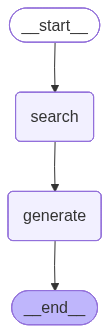


--- Final Answer ---
As of 01:30 PM on May 25, 2026, the current weather in Ahmedabad is as follows:

- **Condition**: Overcast
- **Temperature**: 36°C (Feels like 35°C)
- **Humidity**: 31%
- **Wind Speed**: 20.9 km/h from the west
- **UV Index**: 10.4 (Extreme)
- **Air Pressure**: 1006 mb
- **Cloud Cover**: 0%
- **Visibility**: 5 km
- **Precipitation**: 0 mm (0% chance of rain)

Overall, the weather is expected to remain dry throughout the day. For more details, you can check the full forecast [here](https://www.aqi.in/weather/in/india/gujarat/ahmedabad).


In [100]:
import os
from typing_extensions import TypedDict
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_openrouter import ChatOpenRouter

load_dotenv()

# Updated State: Added final_answer to store the LLM output
class WebSearchState(TypedDict):
    query: str
    results: list | None
    final_answer: str | None 

# Node 1: Search the web
def search_node(state: WebSearchState):
    tool = TavilySearchResults(max_results=3)
    results = tool.invoke({"query": state["query"]})
    return {"results": results}

# Node 2: Generate answer using LLM
def generate_answer_node(state: WebSearchState):
    llm = ChatOpenRouter(model="gpt-4o-mini", temperature=0)
    
    prompt = f"""You are a helpful assistant. Answer the user query using the provided web search results.
    
    User Query: {state['query']}
    Search Results: {state['results']}
    
    Answer:"""
    
    response = llm.invoke(prompt)
    return {"final_answer": response.content}

# Build the graph
tavily_agent_builder = StateGraph(WebSearchState)

# Add both nodes
tavily_agent_builder.add_node("search", search_node)
tavily_agent_builder.add_node("generate", generate_answer_node)

# Define sequential flow
tavily_agent_builder.add_edge(START, "search")
tavily_agent_builder.add_edge("search", "generate") 
tavily_agent_builder.add_edge("generate", END)      
tavily_agent = tavily_agent_builder.compile()


display(Image(tavily_agent.get_graph(xray=True).draw_mermaid_png()))

response = tavily_agent.invoke({"query": "What is the current weather in Ahmedabad?"})
print("\n--- Final Answer ---")
print(response["final_answer"])


### Capabilities

#### Persistence

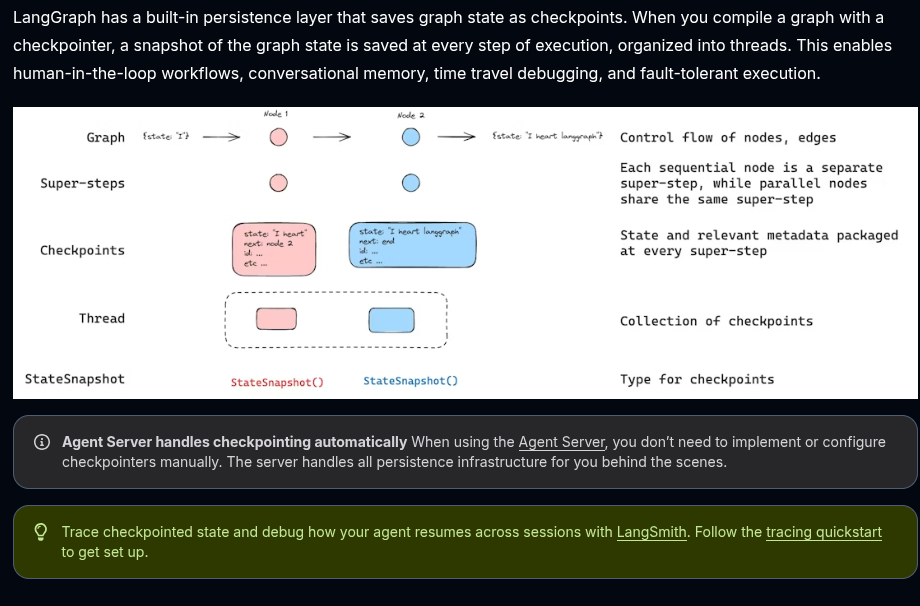

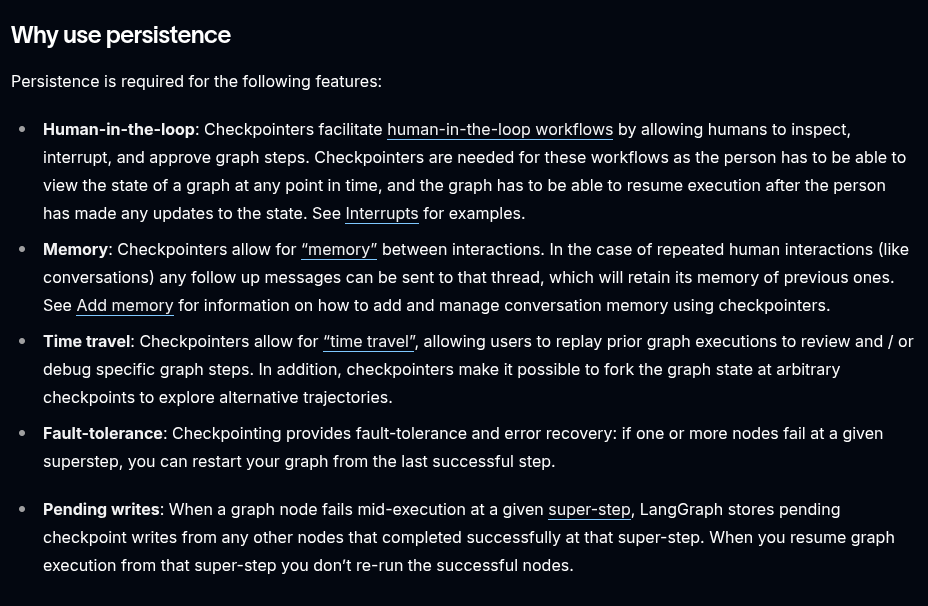

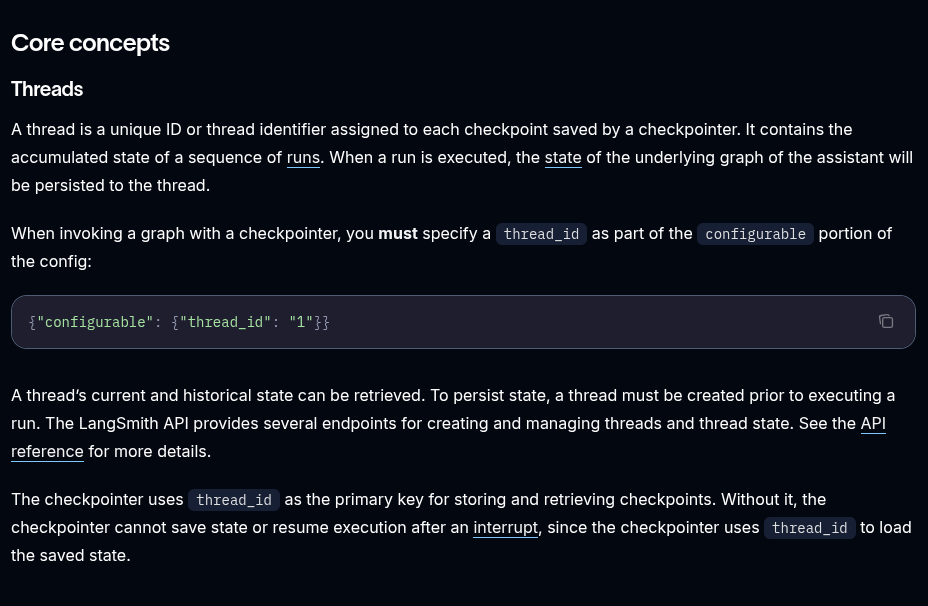

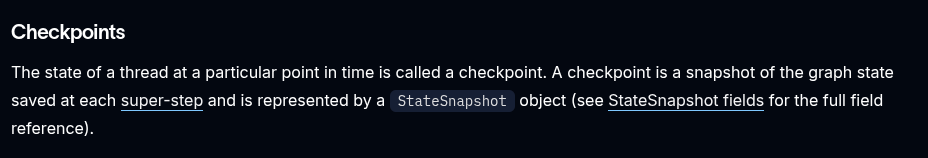

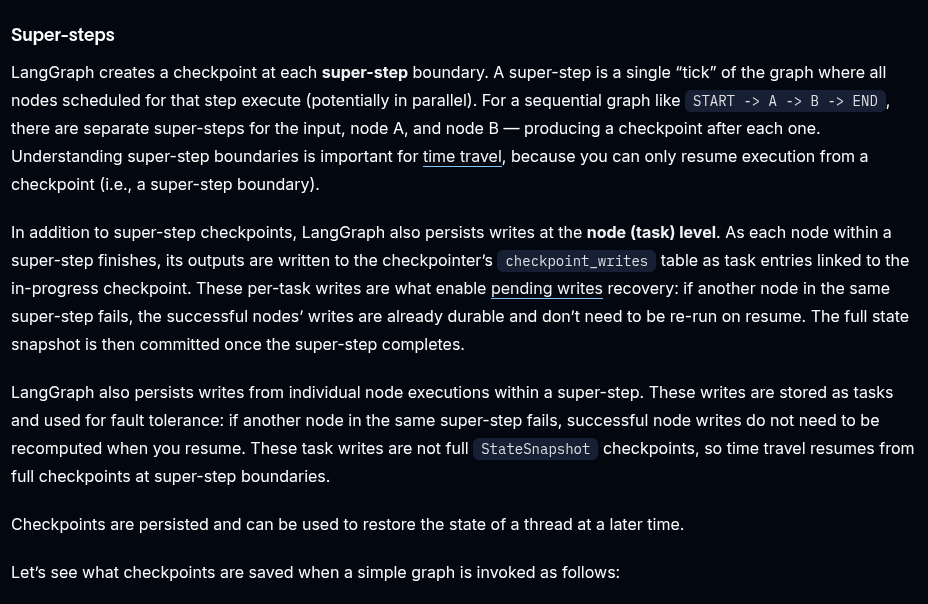

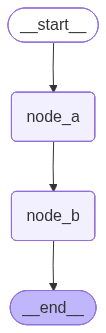

a: 
 {'foo': '', 'bar': []}
b: 
 {'foo': 'a', 'bar': ['a']}


{'foo': 'b', 'bar': ['a', 'b']}

In [53]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.runnables import RunnableConfig
from typing import Annotated
from typing_extensions import TypedDict
from operator import add
from IPython.display import Image 


class State(TypedDict):
    foo: str
    bar: Annotated[list[str], add]

def node_a(state: State):
    print('a: \n',state)
    return {"foo": "a", "bar": ["a"]}

def node_b(state: State):
    print('b: \n',state)
    return {"foo": "b", "bar": ["b"]}


workflow = StateGraph(State)
workflow.add_node(node_a)
workflow.add_node(node_b)
workflow.add_edge(START, "node_a")
workflow.add_edge("node_a", "node_b")
workflow.add_edge("node_b", END)

checkpointer = InMemorySaver()
graph = workflow.compile(checkpointer=checkpointer)

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

config: RunnableConfig = {"configurable": {"thread_id": "1"}}
graph.invoke({"foo": "", "bar":[]}, config)

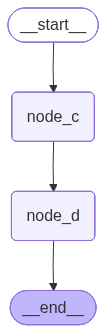

c: 
 {'foo': '', 'bar': []}
d: 
 {'foo': 'c', 'bar': ['c']}


{'foo': 'd', 'bar': ['c', 'd']}

In [106]:
def node_c(state: State):
    print('c: \n',state)
    return {"foo": "c", "bar": ["c"]}

def node_d(state: State):
    print('d: \n',state)
    return {"foo": "d", "bar": ["d"]}


workflow = StateGraph(State)
workflow.add_node(node_c)
workflow.add_node(node_d)
workflow.add_edge(START, "node_c")
workflow.add_edge("node_c", "node_d")
workflow.add_edge("node_d", END)

checkpointer = InMemorySaver()
graph = workflow.compile(checkpointer=checkpointer)

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

config: RunnableConfig = {"configurable": {"thread_id": "2"}}
graph.invoke({"foo": "", "bar":[]}, config)

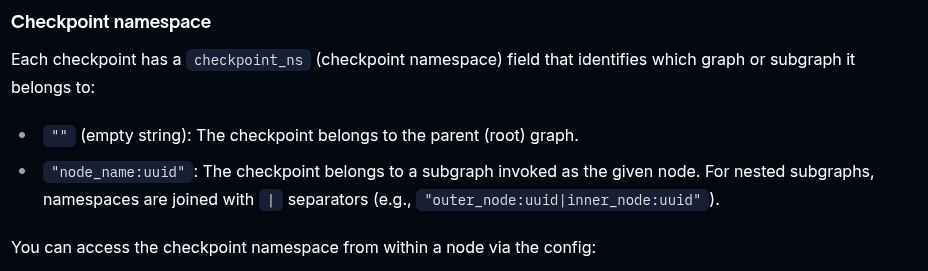

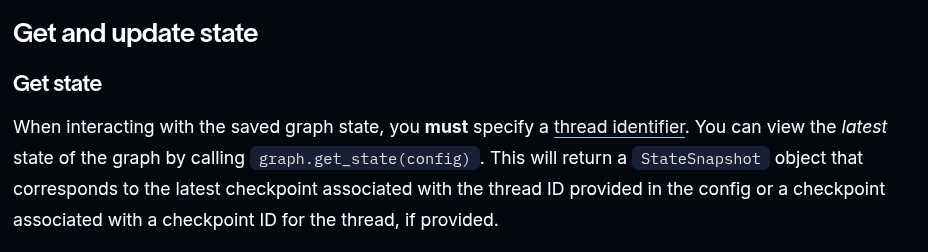

In [54]:
config = {'configurable':{'thread_id':'1'}}
graph.get_state(config)

StateSnapshot(values={'foo': 'b', 'bar': ['a', 'b']}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f157ee7-bcbb-6877-8002-f9530a80bc1f'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-05-25T04:02:01.597750+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f157ee7-bcb9-68ee-8001-eddfcac747eb'}}, tasks=(), interrupts=())

In [107]:
config = {'configurable':{'thread_id':'2'}}
graph.get_state(config)

StateSnapshot(values={'foo': 'd', 'bar': ['c', 'd']}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1581c8-f3c2-6f53-8002-1a4838ca627e'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-05-25T09:31:51.061028+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1581c8-f3bc-69fc-8001-9b164123bfe9'}}, tasks=(), interrupts=())

In [55]:
config = {"configurable": {"thread_id": "1", "checkpoint_id": "1f155d3a-bbad-6769-8001-ad2ef5e448dc"}}
graph.get_state(config)

StateSnapshot(values={}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f155d3a-bbad-6769-8001-ad2ef5e448dc'}}, metadata=None, created_at=None, parent_config=None, tasks=(), interrupts=())

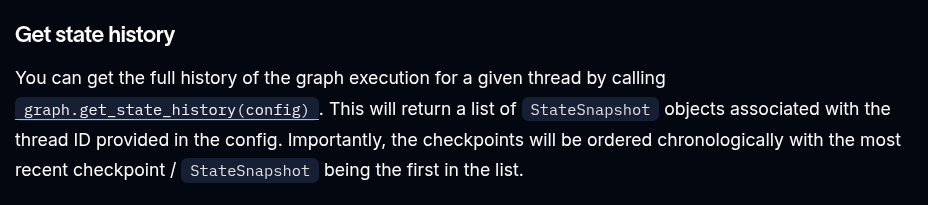

In [57]:
config = {'configurable':{'thread_id':'1'}}
list(graph.get_state_history(config))

[StateSnapshot(values={'foo': 'b', 'bar': ['a', 'b']}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f157ee7-bcbb-6877-8002-f9530a80bc1f'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-05-25T04:02:01.597750+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f157ee7-bcb9-68ee-8001-eddfcac747eb'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'foo': 'a', 'bar': ['a']}, next=('node_b',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f157ee7-bcb9-68ee-8001-eddfcac747eb'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-05-25T04:02:01.596942+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f157ee7-bcb6-694c-8000-9e1753ccdc1e'}}, tasks=(PregelTask(id='e4f92ac8-db28-43d9-4323-230080f62908', name='node_b', path=('__pregel_pull', 'node_b'), error=None, interrupts

In [108]:
config = {'configurable':{'thread_id':'2'}}
list(graph.get_state_history(config))

[StateSnapshot(values={'foo': 'd', 'bar': ['c', 'd']}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1581c8-f3c2-6f53-8002-1a4838ca627e'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-05-25T09:31:51.061028+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1581c8-f3bc-69fc-8001-9b164123bfe9'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'foo': 'c', 'bar': ['c']}, next=('node_d',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1581c8-f3bc-69fc-8001-9b164123bfe9'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-05-25T09:31:51.058426+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1581c8-f3b8-6f4c-8000-d5d072894475'}}, tasks=(PregelTask(id='1f142f22-dd7f-1140-fc49-3e8610f359d4', name='node_d', path=('__pregel_pull', 'node_d'), error=None, interrupts

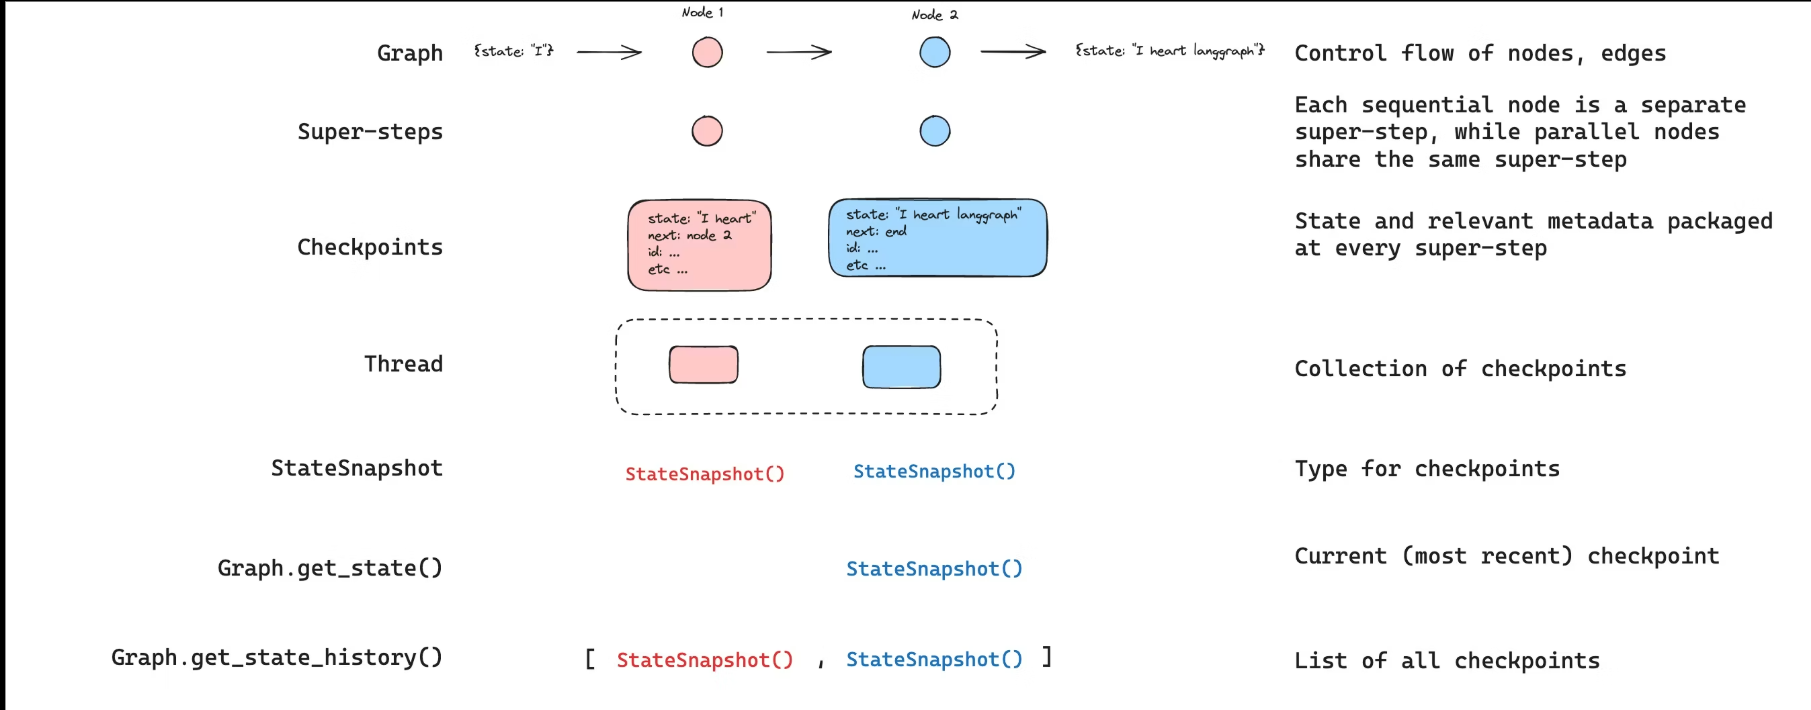

In [63]:
history = list(graph.get_state_history(config))

# Find the checkpoint before a specific node executed
before_node_b = next(s for s in history if s.next == ("node_b",))

In [61]:
before_node_b

StateSnapshot(values={'foo': '', 'bar': []}, next=('node_a',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f157ee7-bcb6-694c-8000-9e1753ccdc1e'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-05-25T04:02:01.595709+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f157ee7-bcb4-66a6-bfff-1685a5c401d4'}}, tasks=(PregelTask(id='20f4e533-c9ba-80cd-5103-6e2b9aa5bd5a', name='node_a', path=('__pregel_pull', 'node_a'), error=None, interrupts=(), state=None, result={'foo': 'a', 'bar': ['a']}),), interrupts=())

##### Memory Store

In [65]:
from langgraph.store.memory import InMemoryStore
import uuid

store = InMemoryStore()

user_id='1'
namespace_for_memory = (user_id, 'memories')

memory_id = str(uuid.uuid4())
memory = {'food_preference':'I like pizza'}
store.put(namespace_for_memory, memory_id, memory)

memories = store.search(namespace_for_memory)
memories[-1].dict()

{'namespace': ['1', 'memories'],
 'key': '9bec1fa7-0551-4b94-9ddf-cf119ca819fd',
 'value': {'food_preference': 'I like pizza'},
 'created_at': '2026-05-25T04:28:22.765469+00:00',
 'updated_at': '2026-05-25T04:28:22.765472+00:00',
 'score': None}

- Listing items in namespace,

In [ ]:
items = store.search(('alice','memories'), limit=100)
items

[]

- To discover which namespaces exist,

In [70]:
namespaces = store.list_namespaces(prefix=('1',), max_depth=2)
namespaces

[('1', 'memories')]

- Semantic search

In [ ]:
from langchain_nomic import NomicEmbeddings

embeddings = NomicEmbeddings(model="nomic-embed-text-v1.5")

store = InMemoryStore(
    index={
        "embed": embeddings,  
        "dims": 1536,                              
        "fields": ["food_preference", "$"]
    }
)

store.put(
    namespace_for_memory,
    str(uuid.uuid4()),
    {
        'food_preference':'I love Italian cuisine',
        'context':'Discussing dinner plans'
    },
    index=['food_preference'] # to only embed this field only
)

memories = store.search(
    namespace_for_memory,
    query='What does the user like to eat ?',
    limit=3
)

memories

# # Store without embedding (still retrievable, but not searchable)
# store.put(
#     namespace_for_memory,
#     str(uuid.uuid4()),
#     {"system_info": "Last updated: 2024-01-01"},
#     index=False
# )


[Item(namespace=['1', 'memories'], key='c67018ef-e273-4963-96f3-37366fa50fcd', value={'food_preference': 'I love Italian cuisine', 'context': 'Discussing dinner plans'}, created_at='2026-05-25T05:27:25.049790+00:00', updated_at='2026-05-25T05:27:25.049792+00:00', score=0.47840348960148216)]

- Using in LangGraph

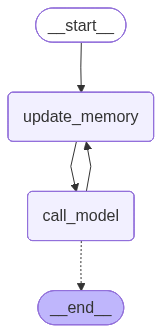

AttributeError: 'NoneType' object has no attribute 'user_id'

In [92]:
from dataclasses import dataclass
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.runtime import Runtime

@dataclass
class Context:
    user_id: str

class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add]
    llm_calls: int

async def update_memory(state: MessagesState, runtime: Runtime[Context]):
    # Get the user id from the runtime context
    user_id = runtime.context.user_id

    # Namespace the memory
    namespace = (user_id, "memories")

    memory = {
        'food_preference':'I like Pizza'
        }

    # Create a new memory ID
    memory_id = str(uuid.uuid4())

    # We create a new memory
    await runtime.store.aput(namespace, memory_id, {"memory": memory})
    return state  # Always return state

async def call_model(state: MessagesState, runtime: Runtime[Context]):
    # Get the user id from the runtime context
    user_id = runtime.context.user_id

    # Namespace the memory
    namespace = (user_id, "memories")

    # Search based on the most recent message
    memories = await runtime.store.asearch(
        namespace,
        query=state["messages"][-1].content,
        limit=3
    )
    info = "\n".join([d.value["memory"] for d in memories])

    # Call the model with the retrieved memories as context
    msg = llm.invoke(f"Here is some relevant information based on your query: {info}\n\n{state['messages'][-1].content}")
    return {"messages": [msg], "llm_calls": state["llm_calls"] + 1} 

workflow = StateGraph(MessagesState)
workflow.add_node("update_memory", update_memory)
workflow.add_node("call_model", call_model)
workflow.add_edge(START, "update_memory")
workflow.add_edge("update_memory", "call_model")
workflow.add_edge("call_model", "update_memory")    
workflow.add_edge("update_memory", END)

app = workflow.compile(checkpointer=InMemorySaver())

display(Image(app.get_graph(xray=True).draw_mermaid_png()))

id1 = await app.ainvoke(
    {"messages": [HumanMessage(content="What is my food preference?")], "llm_calls": 0},
    config={
        "configurable": {"thread_id": "1"},
        "context": Context(user_id="1")
    }
)
id1

##### Checkpointer libraries

#### Durable Execution

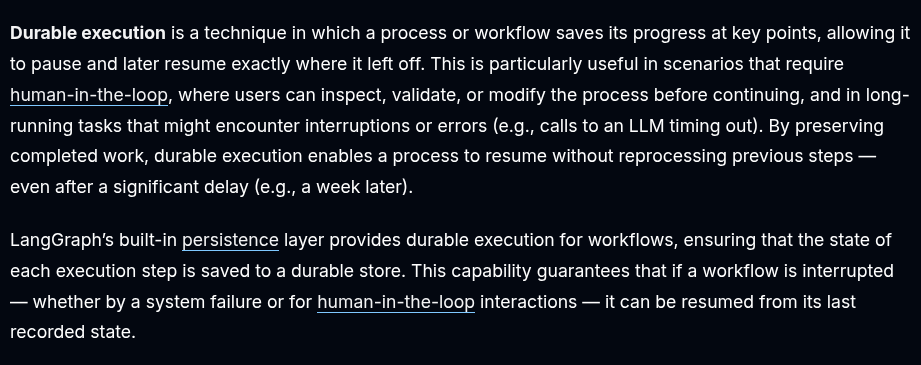

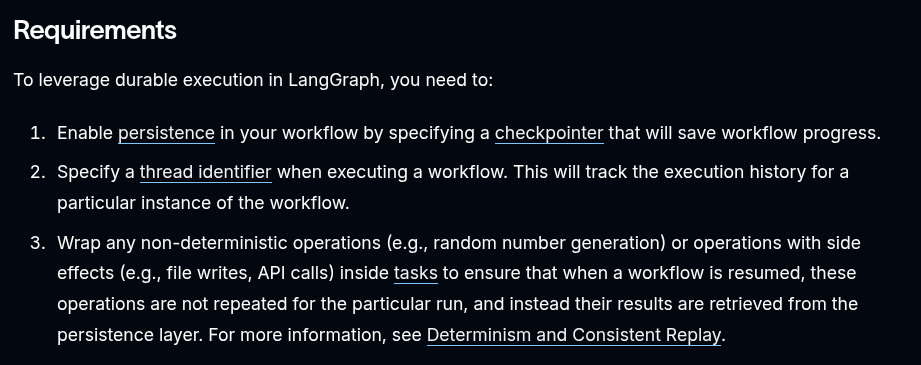

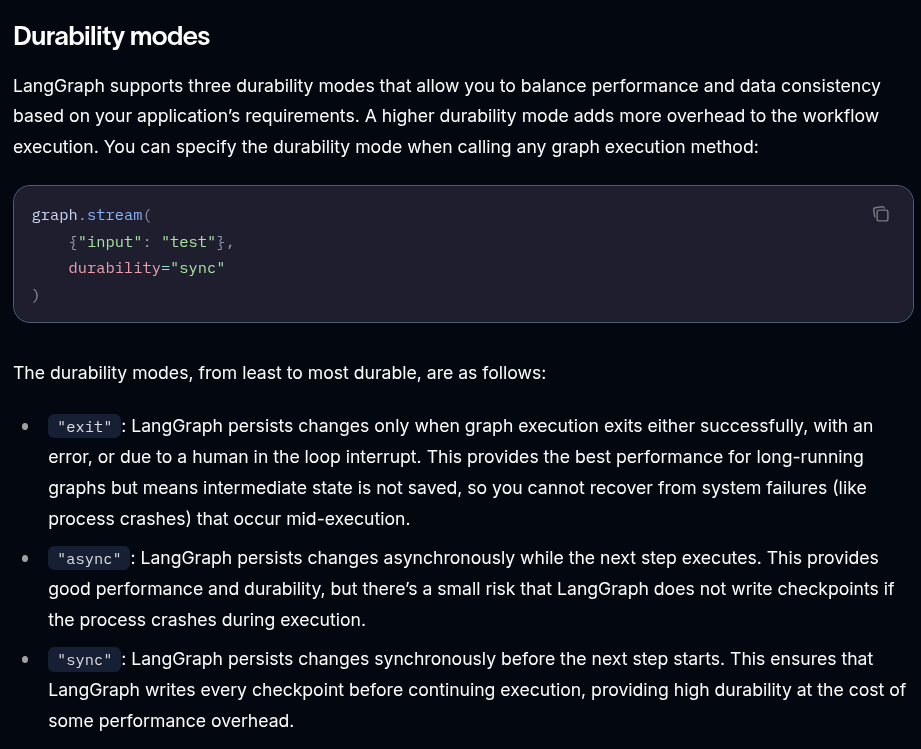

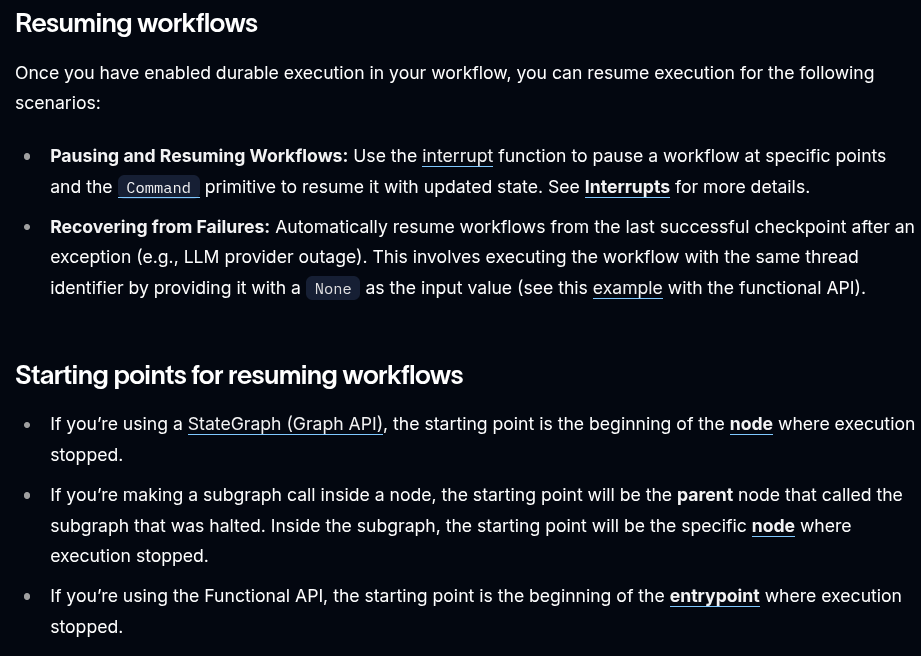

In [ ]:
# DRAIN !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!1

#### Fault Tolerance

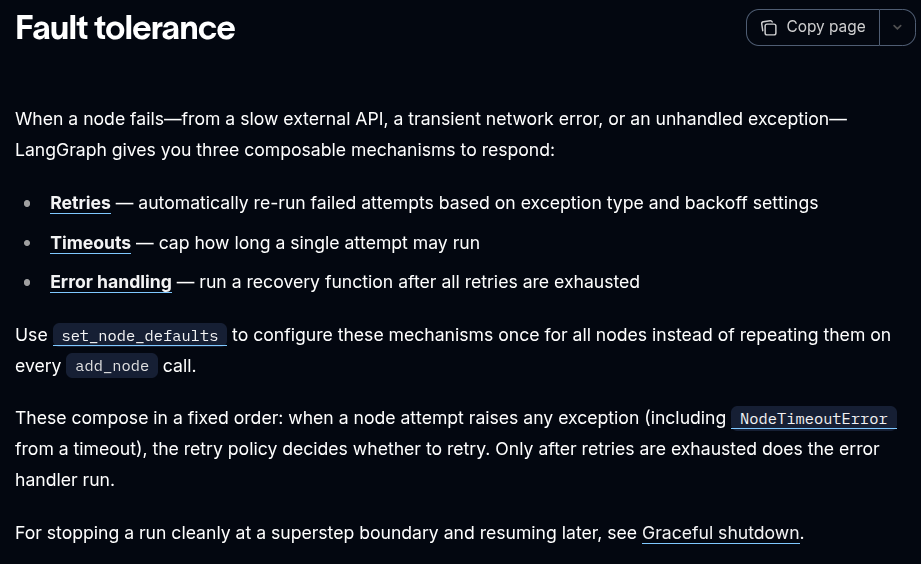

##### Retries

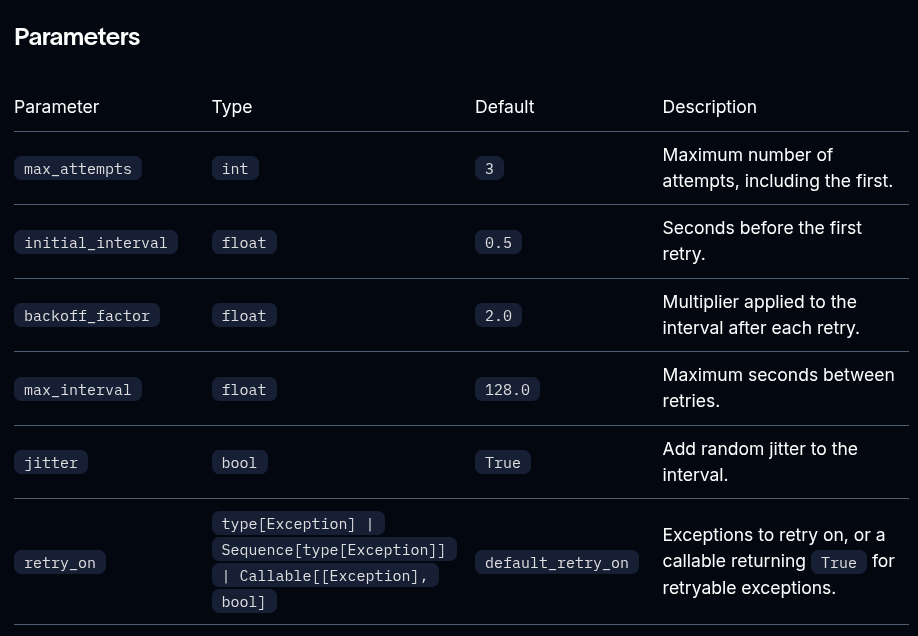

In [ ]:
from langgraph.graph import StateGraph, START, END
from langgraph.runtime import Runtime
from langgraph.types import RetryPolicy
from typing_extensions import TypedDict

class State(TypedDict):
    result: str

def call_primary_api():
    # ...
    return "Primary API result"

def call_fallback_api():
    # ...
    return "Fallback API result"

def my_node(state: State, runtime: Runtime) -> State:
    print('Execution info: ', runtime.execution_info)
    print('Attempt: ', runtime.execution_info.node_attempt)
    
    if runtime.execution_info.node_attempt > 1:
        return {"result": call_fallback_api()}
 
    if runtime.execution_info.node_attempt == 1:
        raise Exception("Simulated failure to trigger retry")

    return {"result": call_primary_api()}

builder = StateGraph(State)
builder.add_node("my_node", my_node, retry_policy=RetryPolicy(max_attempts=2))
builder.add_edge(START, "my_node")
builder.add_edge("my_node", END)
app = builder.compile()
app.invoke({"result": ""})

Execution info:  ExecutionInfo(checkpoint_id='1f15826e-0f0d-6e94-8000-f46a9bafe99f', checkpoint_ns='my_node:10d9bcb7-fba8-5755-a7bc-1e8a0d82b3cc', task_id='10d9bcb7-fba8-5755-a7bc-1e8a0d82b3cc', thread_id=None, run_id=None, node_attempt=1, node_first_attempt_time=1779705943.108348)
Attempt:  1
Execution info:  ExecutionInfo(checkpoint_id='1f15826e-0f0d-6e94-8000-f46a9bafe99f', checkpoint_ns='my_node:10d9bcb7-fba8-5755-a7bc-1e8a0d82b3cc', task_id='10d9bcb7-fba8-5755-a7bc-1e8a0d82b3cc', thread_id=None, run_id=None, node_attempt=2, node_first_attempt_time=1779705943.108348)
Attempt:  2


{'result': 'Fallback API result'}

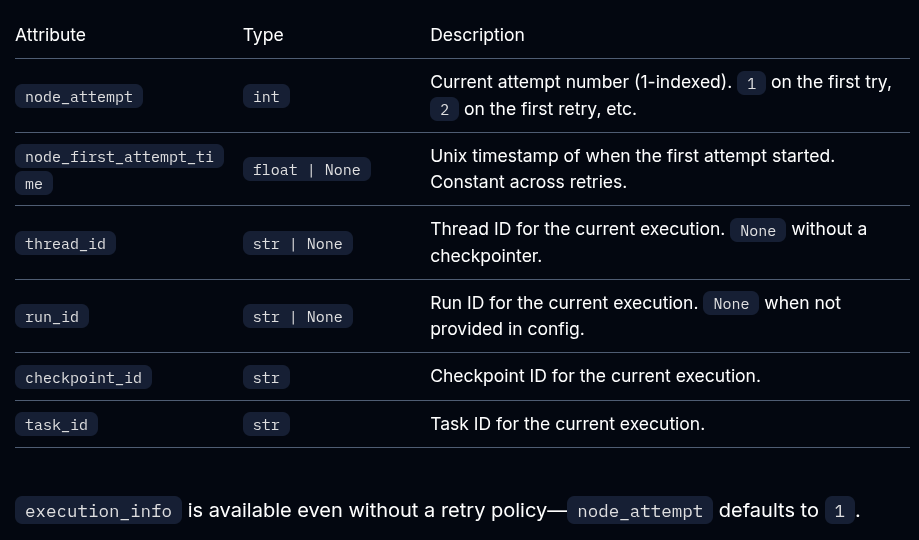

##### Timeouts

In [152]:
from langgraph.graph import StateGraph, START, END
from langgraph.runtime import Runtime
from langgraph.types import TimeoutPolicy
from typing_extensions import TypedDict
import time

class State(TypedDict):
    result: str

def call_primary_api():
    return "Primary API result"

def call_fallback_api():
    return "Fallback API result (timeout fallback)"

def my_node(state: State, runtime: Runtime) -> State:
    # Simulate a long-running operation that will exceed the timeout
    print("Execution info:", runtime.execution_info)
    print("Starting long-running work (will sleep 5s)...")
    time.sleep(5)
    return {"result": call_primary_api()}

builder = StateGraph(State)
builder.add_node(
    "my_node",
    my_node,
    timeout_policy=TimeoutPolicy(run_timeout=2, fallback={"result": call_fallback_api()})
)

builder.add_edge(START, "my_node")
builder.add_edge("my_node", END)

app = builder.compile()
print(app.invoke({"result": ""}))

TypeError: TimeoutPolicy.__init__() got an unexpected keyword argument 'fallback'

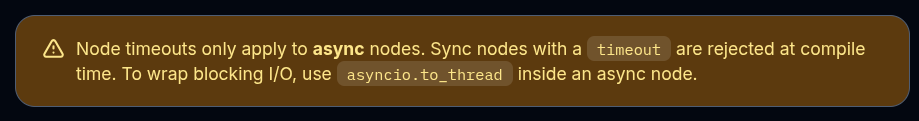

### Persistence / Time travel

In [121]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
import time

class CrashState(TypedDict):
    input: str
    step1: str
    step2: str
    step3: bool

def step_1(state: CrashState) -> CrashState:
    print("✅ Step 1 executed")
    return {"step1": "done", "input": state["input"]}

def step_2(state: CrashState) -> CrashState:
    print("⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)")
    time.sleep(5)  # Simulate long-running hang
    return {"step2": "done"}

def step_3(state: CrashState) -> CrashState:
    print("✅ Step 3 executed")
    return {"step3": "done"}

builder = StateGraph(CrashState)
builder.add_node("step_1", step_1)
builder.add_node("step_2", step_2)
builder.add_node("step_3", step_3)

builder.set_entry_point('step_1')
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")
builder.add_edge("step_3", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

In [122]:
try:
    print("▶️ Running graph: Please manually interrupt during Step 2...")
    graph.invoke({"input": "start"}, config={"configurable": {"thread_id": 'thread-1'}})
except KeyboardInterrupt:
    print("❌ Kernel manually interrupted (crash simulated).")

▶️ Running graph: Please manually interrupt during Step 2...
✅ Step 1 executed
⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)
❌ Kernel manually interrupted (crash simulated).


In [123]:
print("\n🔁 Re-running the graph to demonstrate fault tolerance...")
final_state = graph.invoke(None, config={"configurable": {"thread_id": 'thread-1'}})
print("\n✅ Final State:", final_state)


🔁 Re-running the graph to demonstrate fault tolerance...
⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)
✅ Step 3 executed

✅ Final State: {'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': 'done'}


In [124]:
list(graph.get_state_history({"configurable": {"thread_id": 'thread-1'}}))

[StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': 'done'}, next=(), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f15821c-20e7-6b76-8003-706fe299de87'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-05-25T10:09:03.809001+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f15821c-20e5-64c4-8002-76ccc0c90b8b'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done'}, next=('step_3',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f15821c-20e5-64c4-8002-76ccc0c90b8b'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-05-25T10:09:03.808008+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f15821b-98b1-69bb-8001-7358a94c3e30'}}, tasks=(PregelTask(id='351f2bc2-5ab1-31c1

- Time Travel

In [125]:
intermediate_state = graph.get_state({"configurable": {"thread_id": 'thread-1', "checkpoint_id": '1f15821b-98b1-69bb-8001-7358a94c3e30'}})
print("\n🔍 Intermediate State at Checkpoint:", intermediate_state)


🔍 Intermediate State at Checkpoint: StateSnapshot(values={'input': 'start', 'step1': 'done'}, next=('step_2',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_id': '1f15821b-98b1-69bb-8001-7358a94c3e30'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-05-25T10:08:49.526198+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f15821b-98ad-6703-8000-8b4df2a2b16a'}}, tasks=(PregelTask(id='4012e473-844c-7da7-4cd4-965ce9a4bae7', name='step_2', path=('__pregel_pull', 'step_2'), error=None, interrupts=(), state=None, result={'step2': 'done'}),), interrupts=())


In [126]:
graph.invoke(None, config={"configurable": {"thread_id": 'thread-1', "checkpoint_id": '1f15821b-98b1-69bb-8001-7358a94c3e30'}})

⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)
✅ Step 3 executed


{'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': 'done'}